In [3]:
import pandas as pd  # data handling
import seaborn as sns  # visualization
import matplotlib.pyplot as plt  # plotting

In [5]:
df = pd.read_csv("superstore_full_dataset.csv")  # load dataset
print("Data Loaded Successfully")

Data Loaded Successfully


In [7]:
print("First 5 rows:")
print(df.head())

First 5 rows:
         Order ID Customer Name         Category Sub-Category Product Name  \
0  CA-2016-100000          Omar  Office Supplies  Accessories    Product A   
1  CA-2017-100001          Omar        Furniture       Phones    Product A   
2  CA-2014-100002           Ali        Furniture      Storage    Product A   
3  CA-2016-100003          Sara  Office Supplies  Accessories    Product B   
4  CA-2016-100004         Ahmed  Office Supplies      Storage    Product A   

    Sales  Profit  Discount  Quantity   Region  Order Date  
0  189.34 -142.95      0.37         9     East  2014-01-01  
1  684.31 -124.38      0.07         9    South  2014-01-02  
2  189.62  -87.34      0.38         8  Central  2014-01-03  
3  529.91  -74.52      0.38         1  Central  2014-01-04  
4  711.96  225.31      0.33         2     East  2014-01-05  


In [7]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       500 non-null    object 
 1   Customer Name  500 non-null    object 
 2   Category       500 non-null    object 
 3   Sub-Category   500 non-null    object 
 4   Product Name   500 non-null    object 
 5   Sales          500 non-null    float64
 6   Profit         500 non-null    float64
 7   Discount       500 non-null    float64
 8   Quantity       500 non-null    int64  
 9   Region         500 non-null    object 
 10  Order Date     500 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 43.1+ KB


In [9]:
df.columns = df.columns.str.strip()  # clean column names
print("Columns cleaned")

Columns cleaned


In [11]:
print("Total Sales:")
print(df["Sales"].sum())

print("Sales by Region:")
print(df.groupby("Region")["Sales"].sum())

print("Sales by Category:")
print(df.groupby("Category")["Sales"].sum())

Total Sales:
251587.21000000002
Sales by Region:
Region
Central    65852.49
East       53309.04
South      72411.19
West       60014.49
Name: Sales, dtype: float64
Sales by Category:
Category
Furniture          84129.85
Office Supplies    79299.23
Technology         88158.13
Name: Sales, dtype: float64


In [13]:
print("Total Profit:")
print(df["Profit"].sum())

print("Profit vs Discount:")
print(df.groupby("Discount")["Profit"].mean())

Total Profit:
26207.16
Profit vs Discount:
Discount
0.00     51.465556
0.01     -1.819000
0.02     27.046667
0.03    110.186000
0.04     33.581667
0.05    -55.408333
0.06     32.762500
0.07     88.197778
0.08    123.366250
0.09     10.602500
0.10     95.624545
0.11     48.230000
0.12     73.523000
0.13     74.185714
0.14     96.601875
0.15    137.961333
0.16     88.186250
0.17     97.227000
0.18     53.599231
0.19     26.014000
0.20     31.755385
0.21     43.046250
0.22     52.080000
0.23     62.293333
0.24      2.917500
0.25     35.126429
0.26     76.113333
0.27    -31.131429
0.28     33.208333
0.29    -13.238571
0.30     44.888571
0.31     85.910000
0.32    136.656667
0.33     86.922000
0.34     76.463000
0.35     28.371667
0.36     45.386923
0.37     31.930000
0.38    -52.763846
0.39     89.188889
0.40     12.369167
0.41     42.672857
0.42    -12.853636
0.43     16.985000
0.44    -20.052500
0.45     94.295455
0.46     88.214286
0.47     86.415000
0.48     25.980000
0.49      7.88090

In [31]:
customer_df = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Order ID": "count"
}).reset_index()

customer_df.columns = ["Customer Name", "Total Sales", "Total Orders"]

print("Customer Data:")
print(customer_df.head())

Customer Data:
  Customer Name  Total Sales  Total Orders
0         Ahmed     43171.09            93
1           Ali     41311.79            87
2          Mona     42499.10            81
3          Omar     50433.04            99
4          Sara     39624.71            67


In [17]:
def segment_customer(sales):  # classify customers
    if sales > 10000:
        return "High Value"
    elif sales > 5000:
        return "Medium Value"
    else:
        return "Low Value"

customer_df["Segment"] = customer_df["Total Sales"].apply(segment_customer)

print("Customer Segments:")
print(customer_df.head())

Customer Segments:
  Customer Name  Total Sales  Total Orders     Segment
0         Ahmed     43171.09            93  High Value
1           Ali     41311.79            87  High Value
2          Mona     42499.10            81  High Value
3          Omar     50433.04            99  High Value
4          Sara     39624.71            67  High Value


In [19]:
customer_df["Avg Order Value"] = customer_df["Total Sales"] / customer_df["Total Orders"]

print("Customer Behavior:")
print(customer_df.head())

Customer Behavior:
  Customer Name  Total Sales  Total Orders     Segment  Avg Order Value
0         Ahmed     43171.09            93  High Value       464.205269
1           Ali     41311.79            87  High Value       474.848161
2          Mona     42499.10            81  High Value       524.680247
3          Omar     50433.04            99  High Value       509.424646
4          Sara     39624.71            67  High Value       591.413582


In [33]:
print("Top Customers:")
print(customer_df.sort_values(by="Total Sales", ascending=False).head(10))

Top Customers:
  Customer Name  Total Sales  Total Orders
3          Omar     50433.04            99
0         Ahmed     43171.09            93
2          Mona     42499.10            81
1           Ali     41311.79            87
4          Sara     39624.71            67
5       Youssef     34547.48            73


In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [19]:
df["Month"] = df["Order Date"].dt.month

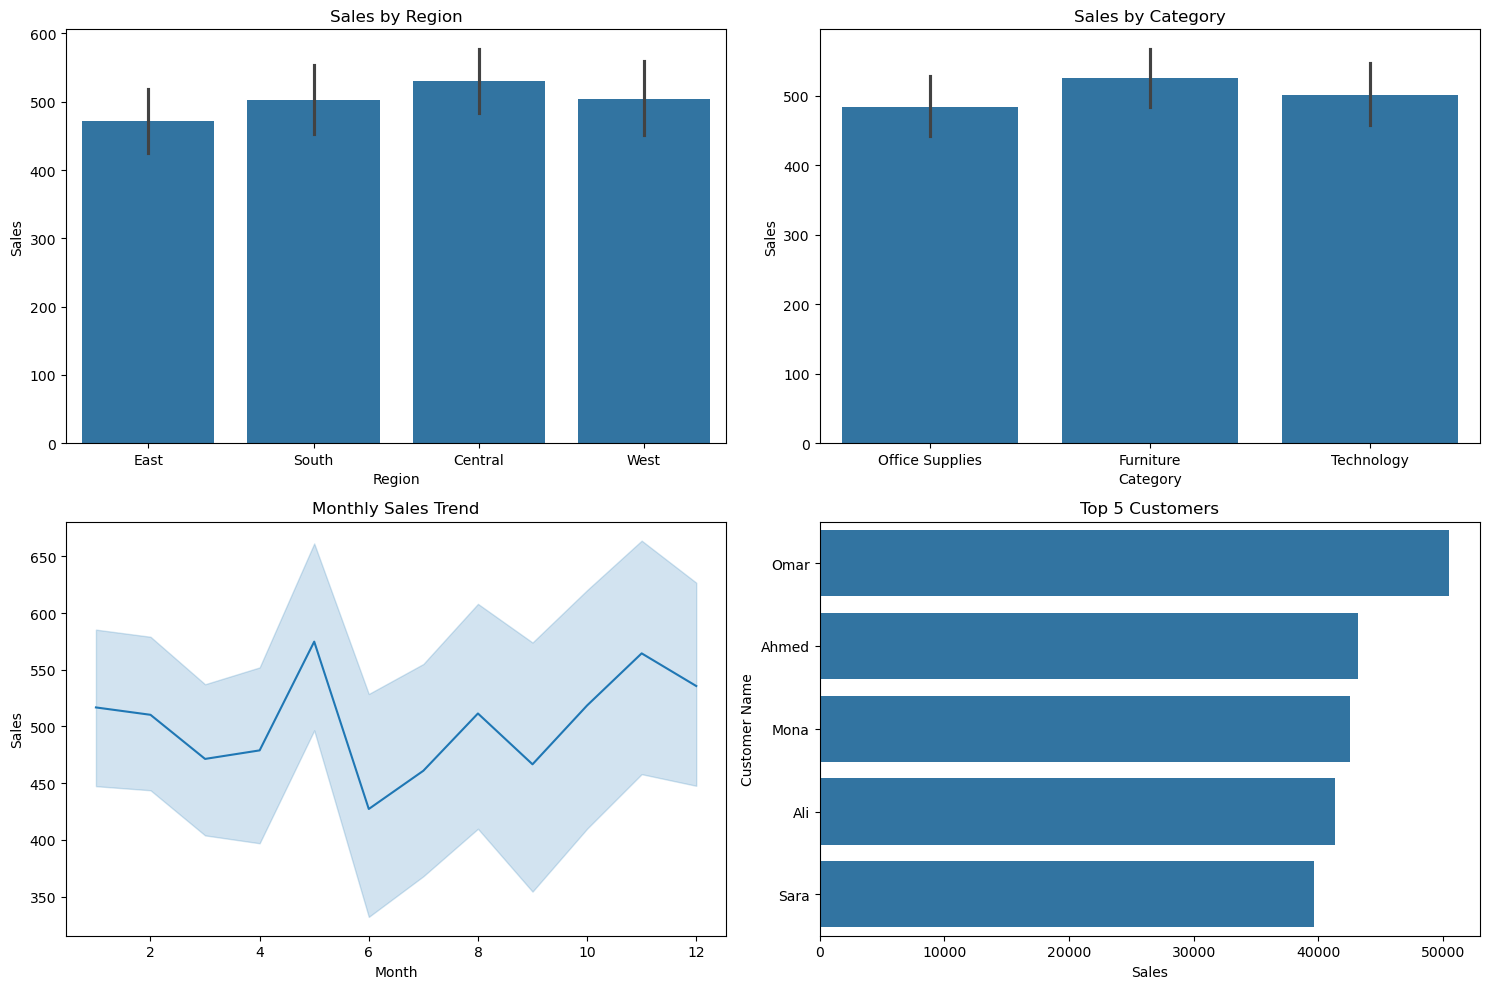

In [29]:
plt.figure(figsize=(15,10))

# Sales by Region
plt.subplot(2,2,1)
sns.barplot(x="Region", y="Sales", data=df)
plt.title("Sales by Region")

# Sales by Category
plt.subplot(2,2,2)
sns.barplot(x="Category", y="Sales", data=df)
plt.title("Sales by Category")

# Monthly Sales
plt.subplot(2,2,3)
sns.lineplot(x="Month", y="Sales", data=df)
plt.title("Monthly Sales Trend")

# Top Customers
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5).reset_index()

plt.subplot(2,2,4)
sns.barplot(x="Sales", y="Customer Name", data=top_customers)
plt.title("Top 5 Customers")

plt.tight_layout()
plt.show()

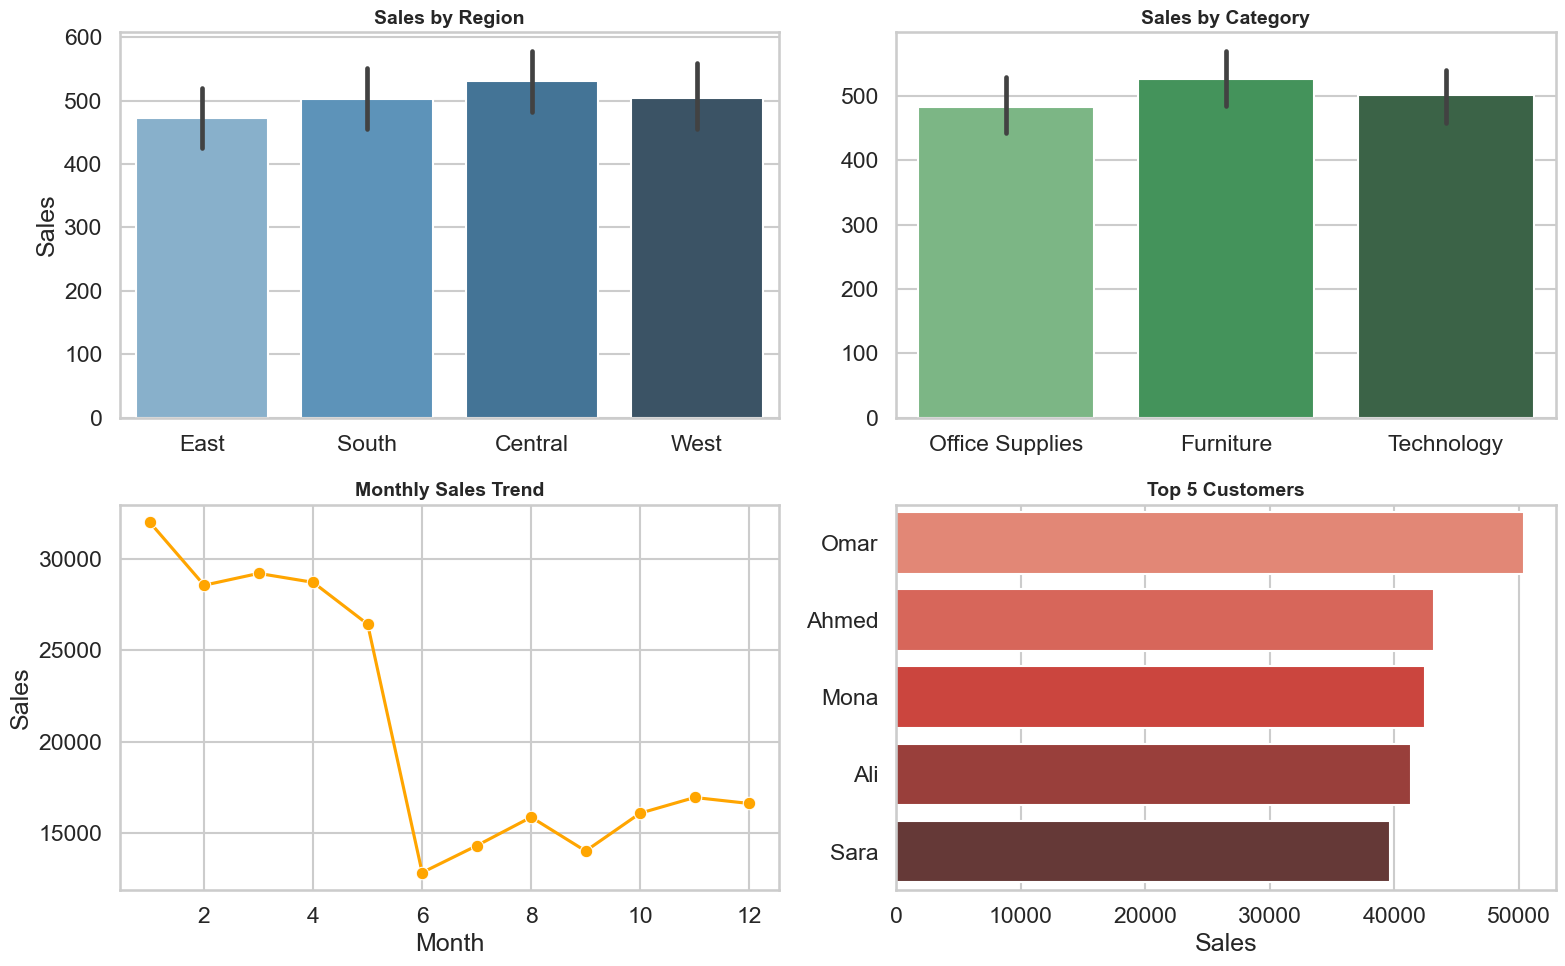

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحسين الشكل العام
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(16,10))

# 1️⃣ Sales by Region
plt.subplot(2,2,1)
sns.barplot(x="Region", y="Sales", data=df, hue="Region", palette="Blues_d", legend=False)
plt.title("Sales by Region", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Sales")

# 2️⃣ Sales by Category
plt.subplot(2,2,2)
sns.barplot(x="Category", y="Sales", data=df, hue="Category", palette="Greens_d", legend=False)
plt.title("Sales by Category", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("")

# 3️⃣ Monthly Sales
plt.subplot(2,2,3)
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()
sns.lineplot(x="Month", y="Sales", data=monthly_sales, marker="o", color="orange")
plt.title("Monthly Sales Trend", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")

# 4️⃣ Top Customers
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5).reset_index()

plt.subplot(2,2,4)
sns.barplot(x="Sales", y="Customer Name", data=top_customers, hue="Customer Name", palette="Reds_d", legend=False)
plt.title("Top 5 Customers", fontsize=14, weight="bold")
plt.xlabel("Sales")
plt.ylabel("")

plt.tight_layout()

# حفظ الصورة
plt.savefig("dashboard.png", dpi=300)

plt.show()